# Drought under climate change

Welcome! 👋  
In this short, hands-on tutorial you’ll get your first taste of a drought workflow and learn how to download and visualise drought data **for your region** — in just a few minutes.

The goal isn’t to learn everything.  
The goal is to **get something meaningful working, fast.**

Ready? Let’s dive in.

## Setting the scene

Imagine you’re ...

### ❓ The question  
We want to understand how climate change is affecting drought conditions in our region. 

### 💧 The drought index: Standardized Precipitation Index (SPI)

One of the most widely used ways to quantify short-term drought is the **Standardized Precipitation Index (SPI)**.  

```{note}
### SPI at a glance

**Standardized Precipitation Index (SPI)**  
The SPI measures how unusual precipitation is over a given time period compared to a long-term climate baseline.

**Interpretation of SPI values**

| SPI value      | Interpretation      |
|----------------|----------------------|
| **> 2.0**      | Extremely wet        |
| **1.5 to 1.99**   | Very wet             |
| **1.0 to 1.49**   | Moderately wet       |
| **-0.99 to 0.99** | Near normal          |
| **-1.0 to -1.49** | Moderately dry       |
| **-1.5 to -1.99** | Severely dry         |
| **< -2.0**     | Extremely dry        |
```

We will be working with **SPI-1**, representing 1-monthly accumulations, in this tutorial.

### How it works

- We look at the **precipitation over a specific period** (here, 6 month) as a proxy for drought.  
- We compare it to the **same month over a historical baseline**.  
- We use climate projections to assess if droughts may occur more often or may become more intense in the future.

With this in hand, we can now move on to download drought data for our region and start visualizing it. 

## Download historical drought conditions 

Let's get our hands on some real data!  
We'll download historical **SPI-6** data from the Climate Data Store (CDS) using the **CDS API**. If you haven't set it up yet, you can find instructions [here]().  

The data will be stored in a file called:
`drought_historical.nc`
and contains SPI-6 values for **all land grid points within a selected region.** 


In [2]:
import cdsapi
import zipfile
import os

# File names
zip_file = "era5_drought_latest_snapshot.zip"
nc_file = "SPI1_gamma_global_era5t_moda_ref1991to2020_202510.nc"  # inside the zip

dataset = "derived-drought-historical-monthly"
request = {
    "variable": ["standardised_precipitation_index"],
    "accumulation_period": ["1"],
    "version": "1_0",
    "product_type": ["reanalysis"],
    "dataset_type": "intermediate_dataset",
    "year": ["2025"],
    "month": ["10"]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(zip_file)

# Extract the NetCDF file from the zip
with zipfile.ZipFile(zip_file, 'r') as z:
    z.extract(nc_file, path=".")

print(f"Data extracted to {nc_file}")

2025-11-28 15:56:12,443 WARNING [2025-10-30T00:00:00] Downloading data from this dataset requires that the user be registered with the CDS. The use of the API requires a CDS API key.
2025-11-28 15:56:12,444 INFO Request ID is db840ae9-f906-4068-8364-96f53803b0c3
2025-11-28 15:56:12,478 INFO status has been updated to accepted
2025-11-28 15:56:20,757 INFO status has been updated to running
2025-11-28 15:56:25,851 INFO status has been updated to successful


6a1b3fe2271365ab5663675bd37475a6.zip:   0%|          | 0.00/7.95M [00:00<?, ?B/s]

Data extracted to SPI1_gamma_global_era5t_moda_ref1991to2020_202510.nc


**What just happened?**

1. We specified the dataset (`derived-drought-historical-monthly` → ERA5-Drought) and the variable we are interested in (SPI → `standardised_precipitation_index`).
2. We requested the 1-month accumulation SPI (→ `accumulation_period: [1]`).
3. Using the CDS API, we downloaded the file to → `era5_drought_latest_snapshot.zip` and extracted the netCDF file `SPI1_gamma_global_era5t_moda_ref1991to2020_202510.nc` that contains the global snapshot of SPI-1 at the end of October 2025.

Once this cell finishes running, you'll have a complete global SPI-1 snapshot ready for visualization and analysis!

## Read the data

With the data downloaded, the next step is to load it into Python and get a feel for its structure.
We’ll use xarray, which makes working with multi-dimensional NetCDF data easy.

In [3]:
import xarray as xr

# Open the downloaded SPI NetCDF file
ds = xr.open_dataset(nc_file)

# Take a quick look at the dataset
ds

/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.31.0
  warnings.warn(


<xarray.Dataset> Size: 8MB
Dimensions:  (time: 1, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-10-01T06:00:00
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    SPI1     (time, lat, lon) float64 8MB ...
Attributes: (12/17)
    title:                   SPI1
    description:             Drought Index: Standardized Drought Index calcul...
    Conventions:             CF-1.8
    history:                 Created 14/11/2025 12:46:22 using DRYFALL.
    institution:             European Centre for Medium-Range Weather Forecasts
    source:                  DRYFALL v1.0
    ...                      ...
    extent:                  -180,-90,180,90
    resolution:              0.25x0.25
    climate_start_date:      1991-01-01
    climate_end_date:        2020-12-31
    frequency:               Monthly
    contact_person:          support@ecmwf.int

### Explore the dataset
`ds` contains a 3D array with the name `SPI1` with dimensions time, lat, lon. 

You can quickly inspect a slice, for example selecting a time step:
```python
ds['SPI1'].isel(time=0)
```
Since we only downloaded one time step, `ds` also only contains one time step. 

This is a great moment to check that the data loaded correctly and understand its structure before plotting.

## Plot a map of the SPI-1

Now comes the fun part: creating a global map of drought conditions using SPI-1!

We’ll use matplotlib and cartopy for plotting:

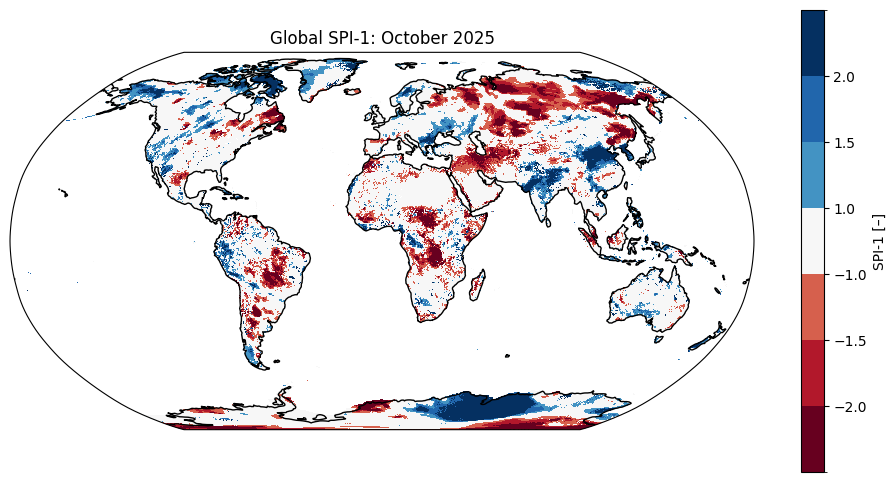

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as colors

# Select the SPI-1 variable for the first (and only) time slice
spi1 = ds['SPI1'].isel(time=0)


# SPI classification edges (from the table above)
spi_levels = [-999, -2.0, -1.5, -1.0, 1.0, 1.5, 2.0, 999]

# Matching colors (dry → wet), using colorblind-safe palette
spi_colors = [
    "#67001f",  # < -2.0   Extremely dry
    "#b2182b",  # -2.0–-1.5
    "#d6604d",  # -1.5–-1.0
    "#f7f7f7",  # -0.99–0.99  near normal
    "#4393c3",  # 1.0–1.5
    "#2166ac",  # 1.5–2.0
    "#053061",  # > 2.0 extremely wet
]

cmap = colors.ListedColormap(spi_colors)
norm = colors.BoundaryNorm(spi_levels, cmap.N)

# Plot
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())

spi1.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    cbar_kwargs={
        "label": "SPI-1 [–]",
        "ticks": [-2, -1.5, -1, 1, 1.5, 2],
    }
)

ax.coastlines()
ax.set_title("Global SPI-1: October 2025")
plt.show()

**What this map shows**

Red areas → regions drier than normal

Blue areas → wetter than normal

White (land) areas → near-normal conditions

With just a few lines of code, you now have a global snapshot of current meteorological drought conditions.

This map can help you quickly identify hotspots where rainfall has been unusually low, ready for further analysis or reporting.

## Wrapping up

Congratulations! 🎉  

In just a few minutes, you’ve:

- Learned what the **Standardized Precipitation Index (SPI)** is and how to interpret it.  
- Downloaded the latest **global SPI-1 snapshot** from ERA5-Drought.  
- Loaded the data into Python and explored its structure.  
- Created a **global map highlighting current drought conditions**.

This is just the beginning. From here, you could:

- Repeat the above but download and visualise the SPEI-1!
- Compare the SPI-1 map to maps from the previous months to see how drought develops over time.
- Compare different accumulation periods to get a feeling for the impact of drought (see more info here: [Understanding Drought (Indices)](explanations/understanding_drought.md)).  
- Zoom into a region of interest to track local drought trends.
- ... and many more! Be creative!


With these steps, you now have a **fast way to monitor drought worldwide**, ready to support further analysis, research, or decision-making.